In [15]:
   !wget -O oulad.zip "https://archive.ics.uci.edu/static/public/349/open+university+learning+analytics+dataset.zip"
   !mkdir -p oulad
   !unzip -o oulad.zip -d oulad
   !ls oulad

--2026-10-07 01:15:28--  https://archive.ics.uci.edu/static/public/349/open+university+learning+analytics+dataset.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘oulad.zip’

oulad.zip               [               <=>  ]  44.58M  13.3MB/s    in 4.3s    

2026-10-07 01:15:34 (10.4 MB/s) - ‘oulad.zip’ saved [46748244]

Archive:  oulad.zip
  inflating: oulad/assessments.csv   
  inflating: oulad/courses.csv       
  inflating: oulad/studentAssessment.csv  
  inflating: oulad/studentInfo.csv   
  inflating: oulad/studentRegistration.csv  
  inflating: oulad/studentVle.csv    
  inflating: oulad/vle.csv           
  inflating: oulad/OULAD.names       
assessments.csv  OULAD.names		studentInfo.csv		 studentVle.csv
courses.csv	 studentAssessment.csv	studentRegistration.csv  vle.csv


# CS-13410 Semester Project — Part 1: Data Preparation & Leakage-Free Pipeline
**Project:** Early prediction of student disengagement (withdrawal) — built for the Study-Sync learning platform
**Course:** Introduction to Machine Learning, Fall 2026, The University of Lahore
**Group:** *(sirat jamil -70149113 , Ayesha Zubair -70146508 )*  |  **Repository:** *(--------------)*

> **Attribution note (academic integrity):** the starting structure of this notebook was drafted with help from an AI assistant (Claude, Anthropic). Our group reviewed, ran and adapted it. *(Edit this line to describe what your group changed.)*

**Dataset:** Open University Learning Analytics Dataset (OULAD), CC-BY 4.0. Kuzilek, J., Hlosta, M., & Zdrahal, Z. (2017). Open University Learning Analytics dataset. *Scientific Data, 4*, 170171. https://doi.org/10.1038/sdata.2017.171

## 1. Problem framing

| Item | Decision |
|---|---|
| **Business question** | Can we warn a learner early that they are likely to stop engaging, so Study-Sync can send a reminder, streak nudge or partner prompt *before* they drop out? |
| **Unit of analysis** | One student in one module-presentation (one row per `code_module` + `code_presentation` + `id_student`) |
| **Prediction target** | `withdrew` = 1 if the student's final result is *Withdrawn*, else 0 |
| **Task type** | Supervised **binary classification** |
| **Prediction time (cutoff)** | Only data observed up to day `CUTOFF_DAY` of the course is used as input. Anything after the cutoff is off-limits. |
| **Population** | Students still registered at the cutoff (students who already unregistered are not "at risk" any more) |
| **Success metrics** | Primary: **PR-AUC (average precision)** and **F1 of the withdrawing class**, because the classes are imbalanced and we care about catching the at-risk class. Secondary: ROC-AUC, recall at a fixed precision. Accuracy alone is not used. |
| **Why OULAD suits Study-Sync** | Real learner behaviour (daily click activity, assessment submissions) plus demographics, with more than 1,000 rows, numeric and categorical features, and an explicit withdrawal outcome. Study-Sync's own engagement signals (sessions, streaks, quiz results) map directly onto these feature types. |

**Main leakage risks we control for:** (1) using `final_result` or `date_unregistration` as features, (2) using clicks or assessments *after* the cutoff, (3) fitting imputers/scalers/encoders on test data, (4) the same student appearing in both train and test.

In [16]:
   # ---- Configuration ----
   from pathlib import Path

   DATA_DIR = Path("oulad")
   CUTOFF_DAY = 60
   RANDOM_STATE = 42
   TEST_SIZE = 0.20

In [17]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, OrdinalEncoder, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")
np.random.seed(RANDOM_STATE)

## 2. Dataset: where to get it and how to load it
1. Download the OULAD zip from the official page: https://analyse.kmi.open.ac.uk/open_dataset (license: CC-BY 4.0, so cite it as above).
2. Extract the CSVs into `data/oulad/`. You need: `studentInfo.csv`, `studentRegistration.csv`, `studentVle.csv`, `studentAssessment.csv`, `assessments.csv`.
3. `studentVle.csv` is large (hundreds of MB), so the code below reads it in chunks and keeps only rows up to the cutoff.

**Do not commit the CSVs to GitHub** (size). Add `data/` to `.gitignore` and describe the download step in the README instead.

In [18]:
student_info = pd.read_csv(DATA_DIR / "studentInfo.csv")
registration = pd.read_csv(DATA_DIR / "studentRegistration.csv")
assessments  = pd.read_csv(DATA_DIR / "assessments.csv")
student_assm = pd.read_csv(DATA_DIR / "studentAssessment.csv")

KEYS = ["code_module", "code_presentation", "id_student"]

# studentVle: read in chunks and keep only activity up to the cutoff (no future information ever enters memory)
vle_chunks = []
for chunk in pd.read_csv(DATA_DIR / "studentVle.csv", chunksize=1_000_000,
                         dtype={"id_student": "int32", "id_site": "int32", "date": "int16", "sum_click": "int32"}):
    vle_chunks.append(chunk[chunk["date"] <= CUTOFF_DAY])
student_vle = pd.concat(vle_chunks, ignore_index=True)
del vle_chunks

print("studentInfo:", student_info.shape, "| registration:", registration.shape,
      "| VLE rows kept (<= cutoff):", student_vle.shape, "| student_assessment:", student_assm.shape)
student_info.head()

studentInfo: (32593, 12) | registration: (32593, 5) | VLE rows kept (<= cutoff): (4499256, 6) | student_assessment: (173912, 5)


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass


In [19]:
   for t in (student_info, registration, assessments, student_assm):
       t.replace(["?", " ", ""], np.nan, inplace=True)

   for col in ["date_registration", "date_unregistration"]:
       registration[col] = pd.to_numeric(registration[col], errors="coerce")

   assessments["date"] = pd.to_numeric(assessments["date"], errors="coerce")

   for col in ["date_submitted", "score", "is_banked"]:
       student_assm[col] = pd.to_numeric(student_assm[col], errors="coerce")

   for col in ["num_of_prev_attempts", "studied_credits"]:
       student_info[col] = pd.to_numeric(student_info[col], errors="coerce")

   print(registration[["date_registration", "date_unregistration"]].dtypes)

date_registration      float64
date_unregistration    float64
dtype: object


## 3. Build the cohort and the target
We keep only students who are **still registered at the cutoff** (not unregistered before it, and registered on or before it). The target comes from `final_result`, which is used *only* to build the label and is never a feature.

In [20]:
base = student_info.merge(registration, on=KEYS, how="left")

still_registered = (base["date_unregistration"].isna() | (base["date_unregistration"] > CUTOFF_DAY))
registered_by_cutoff = base["date_registration"].isna() | (base["date_registration"] <= CUTOFF_DAY)
n_before = len(base)
base = base[still_registered & registered_by_cutoff].copy()
print(f"Rows before cohort filter: {n_before:,} | after: {len(base):,} "
      f"(removed {n_before - len(base):,} who had already left or not yet registered at day {CUTOFF_DAY})")

base["withdrew"] = (base["final_result"] == "Withdrawn").astype(int)
print("\nTarget distribution (share):")
print(base["withdrew"].value_counts(normalize=True).rename({0: "stayed (0)", 1: "withdrew (1)"}).round(3))

Rows before cohort filter: 32,593 | after: 26,353 (removed 6,240 who had already left or not yet registered at day 60)

Target distribution (share):
withdrew
stayed (0)      0.851
withdrew (1)    0.149
Name: proportion, dtype: float64


## 4. Feature construction (cutoff-safe)
All features below are computed only from data with `date <= CUTOFF_DAY`.

| Feature | Meaning |
|---|---|
| `total_clicks`, `active_days`, `n_sites` | Overall VLE engagement up to the cutoff |
| `clicks_last14` , `recent_share` | Activity in the final 14 days before the cutoff, and its share of all clicks (a drop-off signal) |
| `days_since_last_active` | Days between last activity and the cutoff (large = already disengaging) |
| `never_active` | Flag: no VLE activity recorded by the cutoff |
| `n_submitted`, `n_due`, `submission_rate`, `mean_score` | Assessments submitted/due by the cutoff and the average score of those submitted |
| demographics / prior study | `gender`, `region`, `highest_education`, `imd_band`, `age_band`, `num_of_prev_attempts`, `studied_credits`, `disability`, `code_module`, `date_registration` |

Deterministic fills (e.g. 0 clicks when a student has no VLE record) are safe to do here because they use no statistics from the data. Statistical imputation is left to the pipeline.

In [21]:
# --- VLE engagement features ---
g = student_vle.groupby(KEYS)
vle_feat = pd.DataFrame({
    "total_clicks": g["sum_click"].sum(),
    "active_days": g["date"].nunique(),
    "n_sites": g["id_site"].nunique(),
    "last_active_day": g["date"].max(),
})
recent = student_vle[student_vle["date"] > CUTOFF_DAY - 14].groupby(KEYS)["sum_click"].sum().rename("clicks_last14")
vle_feat = vle_feat.join(recent).reset_index()

# --- Assessment features (only submissions up to the cutoff) ---
sa = student_assm.merge(assessments[["id_assessment", "code_module", "code_presentation", "date"]],
                        on="id_assessment", how="left")
sa = sa[sa["date_submitted"] <= CUTOFF_DAY]
assm_feat = (sa.groupby(KEYS)
               .agg(n_submitted=("id_assessment", "nunique"), mean_score=("score", "mean"))
               .reset_index())

# number of assessments that were due by the cutoff, per module-presentation
due = (assessments[assessments["date"] <= CUTOFF_DAY]
       .groupby(["code_module", "code_presentation"]).size().rename("n_due").reset_index())

# --- Assemble the modelling table ---
df = (base.merge(vle_feat, on=KEYS, how="left")
          .merge(assm_feat, on=KEYS, how="left")
          .merge(due, on=["code_module", "code_presentation"], how="left"))

# deterministic fills (no data statistics involved)
for c in ["total_clicks", "active_days", "n_sites", "clicks_last14", "n_submitted", "n_due"]:
    df[c] = df[c].fillna(0)
df["never_active"] = df["last_active_day"].isna().astype(int)
df["days_since_last_active"] = (CUTOFF_DAY - df["last_active_day"]).fillna(CUTOFF_DAY + 1)
df["recent_share"] = df["clicks_last14"] / (df["total_clicks"] + 1)
df["submission_rate"] = np.where(df["n_due"] > 0, df["n_submitted"] / df["n_due"], np.nan)
df["imd_band"] = df["imd_band"].astype("string").str.replace("%", "", regex=False)

print(df.shape)
df.head()

(26353, 27)


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,...,n_sites,last_active_day,clicks_last14,n_submitted,mean_score,n_due,never_active,days_since_last_active,recent_share,submission_rate
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100,55<=,0,240,...,33.0,54.0,42.0,2.0,81.5,2.0,0,6.0,0.079245,1.0
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30,35-55,0,60,...,34.0,53.0,44.0,2.0,69.0,2.0,0,7.0,0.065672,1.0
2,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60,35-55,0,60,...,38.0,60.0,83.0,2.0,71.5,2.0,0,0.0,0.101591,1.0
3,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60,0-35,0,60,...,35.0,60.0,4.0,1.0,69.0,2.0,0,0.0,0.006601,0.5
4,AAA,2013J,38053,M,Wales,A Level or Equivalent,80-90,35-55,0,60,...,42.0,60.0,129.0,1.0,79.0,2.0,0,0.0,0.128231,0.5


## 5. Data quality checks and the final feature list
We separate the **target**, the **identifiers/grouping columns** and the **leakage columns** (excluded on purpose) from the model inputs.

In [22]:
TARGET = "withdrew"
GROUP_COL = "id_student"                       # used for splitting only, never as a feature
LEAKY_OR_ID = ["final_result", "date_unregistration", "last_active_day", "code_presentation", "id_student"]

ORDINAL_COLS = ["imd_band", "age_band", "highest_education"]
NOMINAL_COLS = ["gender", "region", "disability", "code_module"]
SKEWED_NUM   = ["total_clicks", "clicks_last14", "active_days", "n_sites", "days_since_last_active"]
OTHER_NUM    = ["recent_share", "never_active", "n_submitted", "n_due", "submission_rate", "mean_score",
                "num_of_prev_attempts", "studied_credits", "date_registration"]

FEATURES = ORDINAL_COLS + NOMINAL_COLS + SKEWED_NUM + OTHER_NUM
assert not set(FEATURES) & set(LEAKY_OR_ID + [TARGET]), "A leaky column slipped into the feature list!"

X = df[FEATURES]
y = df[TARGET]
groups = df[GROUP_COL]

print("Rows:", len(df), "| Features:", len(FEATURES), "| Duplicate student-module-presentation rows:",
      df.duplicated(KEYS).sum())
print("\nMissing values per feature (count):")
print(X.isna().sum()[X.isna().sum() > 0].sort_values(ascending=False))

Rows: 26353 | Features: 21 | Duplicate student-module-presentation rows: 0

Missing values per feature (count):
submission_rate      2403
mean_score           2352
imd_band              997
date_registration       7
dtype: int64


## 6. Train/test split (before any fitting)
A student can appear in more than one module-presentation, so we split **by student** (`GroupShuffleSplit`). Otherwise the same person could sit in both train and test and inflate the scores. The test set stays untouched until the final evaluation in Part 3.

In [23]:
splitter = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
train_idx, test_idx = next(splitter.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
g_train = groups.iloc[train_idx]

assert set(groups.iloc[train_idx]).isdisjoint(set(groups.iloc[test_idx])), "Student overlap between train and test!"
print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print("Withdrawal rate  train:", round(y_train.mean(), 3), "| test:", round(y_test.mean(), 3))

Train: (21064, 21) | Test: (5289, 21)
Withdrawal rate  train: 0.15 | test: 0.146


## 7. Exploratory data analysis (training set only)
EDA uses `X_train` only, so no insight is drawn from the test set.

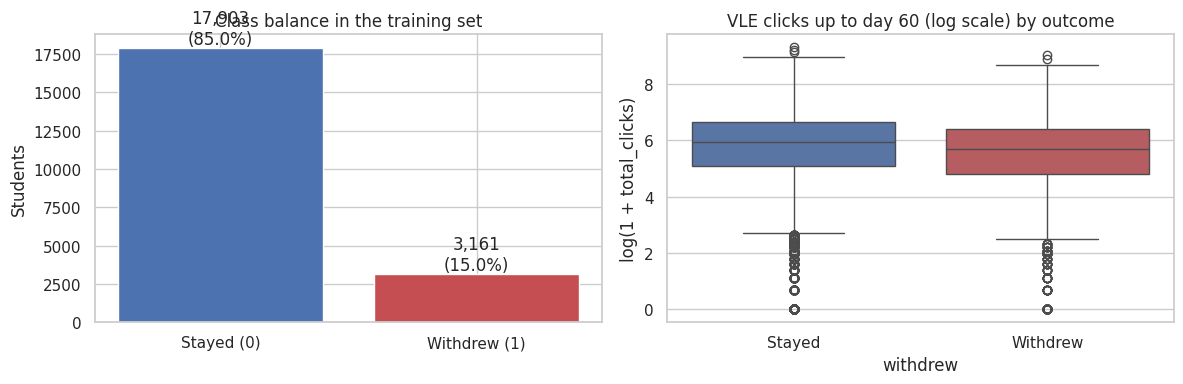

In [24]:
eda = X_train.copy()
eda[TARGET] = y_train.values

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Viz 1: class balance
counts = eda[TARGET].value_counts().sort_index()
axes[0].bar(["Stayed (0)", "Withdrew (1)"], counts.values, color=["#4C72B0", "#C44E52"])
axes[0].set_title("Class balance in the training set")
axes[0].set_ylabel("Students")
for i, v in enumerate(counts.values):
    axes[0].text(i, v, f"{v:,}\n({v/len(eda):.1%})", ha="center", va="bottom")

# Viz 2: engagement distribution by outcome (log scale)
sns.boxplot(data=eda, x=TARGET, y=np.log1p(eda["total_clicks"]), ax=axes[1], palette=["#4C72B0", "#C44E52"], hue=TARGET, legend=False)
axes[1].set_xticks([0, 1]); axes[1].set_xticklabels(["Stayed", "Withdrew"])
axes[1].set_title(f"VLE clicks up to day {CUTOFF_DAY} (log scale) by outcome")
axes[1].set_ylabel("log(1 + total_clicks)")
plt.tight_layout(); plt.show()

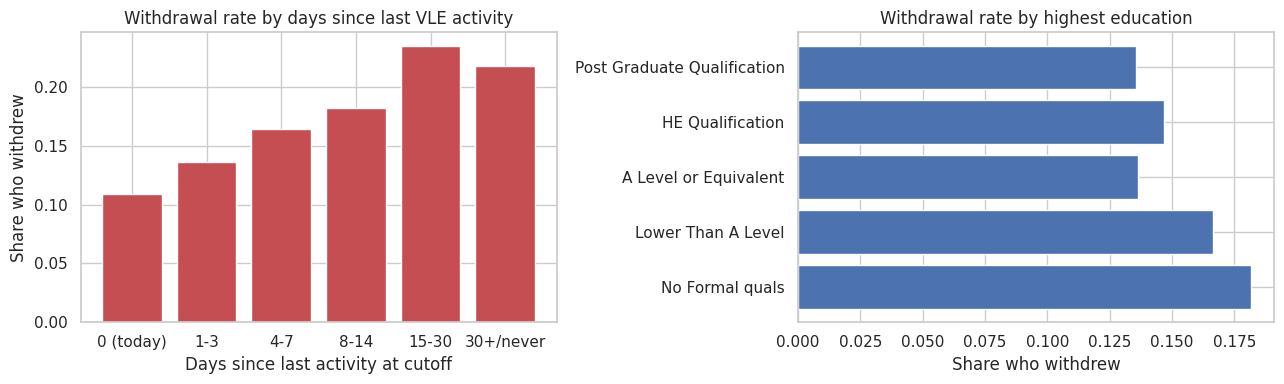

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Viz 3: withdrawal rate by days since last activity
bins = [-1, 0, 3, 7, 14, 30, CUTOFF_DAY + 1]
labels = ["0 (today)", "1-3", "4-7", "8-14", "15-30", "30+/never"]
eda["inactive_bin"] = pd.cut(eda["days_since_last_active"], bins=bins, labels=labels)
rate = eda.groupby("inactive_bin", observed=True)[TARGET].agg(["mean", "size"])
axes[0].bar(rate.index.astype(str), rate["mean"], color="#C44E52")
axes[0].set_title("Withdrawal rate by days since last VLE activity")
axes[0].set_ylabel("Share who withdrew"); axes[0].set_xlabel("Days since last activity at cutoff")

# Viz 4: withdrawal rate by highest education
order = ["No Formal quals", "Lower Than A Level", "A Level or Equivalent", "HE Qualification", "Post Graduate Qualification"]
r2 = eda.groupby("highest_education")[TARGET].mean().reindex(order)
axes[1].barh(order, r2.values, color="#4C72B0")
axes[1].set_title("Withdrawal rate by highest education")
axes[1].set_xlabel("Share who withdrew")
plt.tight_layout(); plt.show()

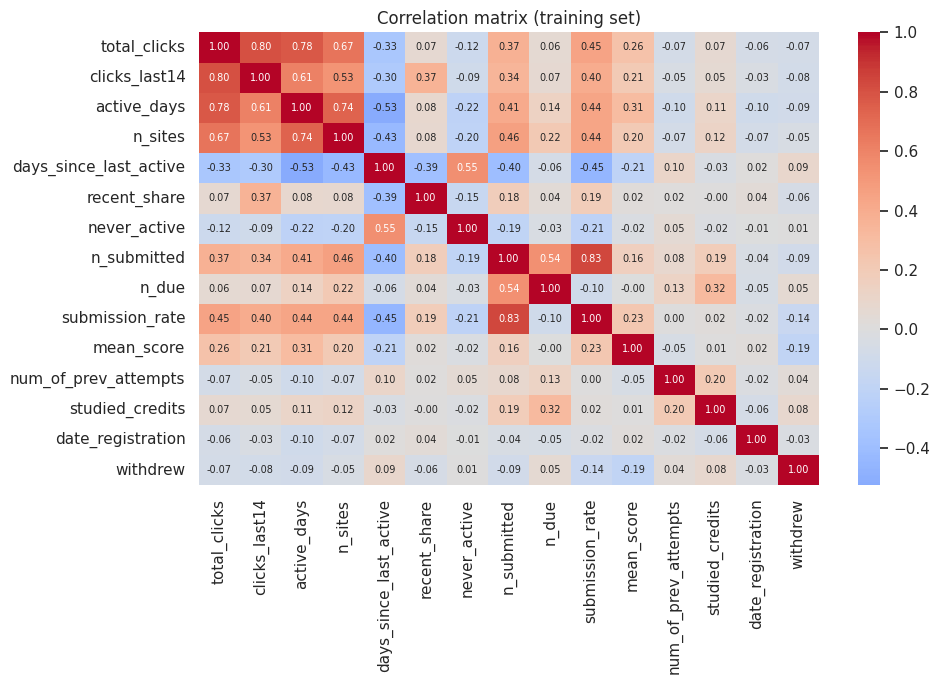

In [26]:
# Viz 5: correlation among numeric features (helps spot redundant features)
num_cols = SKEWED_NUM + OTHER_NUM
corr = eda[num_cols + [TARGET]].corr(numeric_only=True)
plt.figure(figsize=(10, 7))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f", annot_kws={"size": 7})
plt.title("Correlation matrix (training set)")
plt.tight_layout(); plt.show()

**EDA notes — write your own findings here after running the cells** (use the real plots and numbers from your run): class imbalance, which engagement features separate the two groups, which pairs are highly correlated (e.g. `total_clicks` vs `active_days`), and any demographic pattern worth treating with care in the fairness discussion in Part 4.

## 8. Leakage-free preprocessing pipeline
Everything that learns from data (imputation values, scaling statistics, winsorising limits, encoder categories, variance filter) lives **inside** a scikit-learn `Pipeline`/`ColumnTransformer`. It is fitted on training data only and merely *applied* to validation/test data.

| Problem | Handling | Where |
|---|---|---|
| Missing values | Median (numeric, with missing-indicator) / most-frequent (categorical) imputation | fitted on train only |
| Outliers | Winsorise heavy-tailed engagement counts at the 1st/99th percentile, then `log1p` | limits learned on train only |
| Scaling | `StandardScaler` | fitted on train only |
| Encoding | Explicit ordered `OrdinalEncoder` for ordered bands; `OneHotEncoder` for nominal columns | unknown categories at test time are handled safely |
| Feature selection | `VarianceThreshold` removes constant features | fitted on train only |
| Class imbalance | `class_weight="balanced"` in the model plus stratified/grouped CV and PR-AUC/F1 metrics | no resampling of test data |

In [27]:
class Winsorizer(BaseEstimator, TransformerMixin):
    # Clip each column to the [lower, upper] quantiles learned from the training data.
    def __init__(self, lower=0.01, upper=0.99):
        self.lower = lower
        self.upper = upper
    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        self.lo_ = np.nanquantile(X, self.lower, axis=0)
        self.hi_ = np.nanquantile(X, self.upper, axis=0)
        self.n_features_in_ = X.shape[1]
        return self
    def transform(self, X):
        return np.clip(np.asarray(X, dtype=float), self.lo_, self.hi_)
    def get_feature_names_out(self, input_features=None):
        return np.asarray(input_features, dtype=object)

IMD_ORDER = ["0-10", "10-20", "20-30", "30-40", "40-50", "50-60", "60-70", "70-80", "80-90", "90-100"]
AGE_ORDER = ["0-35", "35-55", "55<="]
EDU_ORDER = ["No Formal quals", "Lower Than A Level", "A Level or Equivalent", "HE Qualification", "Post Graduate Qualification"]

ordinal_pipe = Pipeline([
    ("encode", OrdinalEncoder(categories=[IMD_ORDER, AGE_ORDER, EDU_ORDER],
                              handle_unknown="use_encoded_value", unknown_value=np.nan)),
    ("impute", SimpleImputer(strategy="median", add_indicator=True)),
    ("scale", StandardScaler()),
])
nominal_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])
skewed_pipe = Pipeline([
    ("winsor", Winsorizer(0.01, 0.99)),
    ("log", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])
other_num_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median", add_indicator=True)),
    ("scale", StandardScaler()),
])

preprocessor = ColumnTransformer([
    ("ordinal", ordinal_pipe, ORDINAL_COLS),
    ("nominal", nominal_pipe, NOMINAL_COLS),
    ("skewed",  skewed_pipe,  SKEWED_NUM),
    ("other",   other_num_pipe, OTHER_NUM),
], remainder="drop")

preprocessor

ColumnTransformer(transformers=[('ordinal',
                                 Pipeline(steps=[('encode',
                                                  OrdinalEncoder(categories=[['0-10',
                                                                              '10-20',
                                                                              '20-30',
                                                                              '30-40',
                                                                              '40-50',
                                                                              '50-60',
                                                                              '60-70',
                                                                              '70-80',
                                                                              '80-90',
                                                                              '90-100'],
                                                                             ['0-35',
                                                                              '35-55',
                                                                              '55<='],
                                                                             ['No '
                                                                              'Formal '
                                                                              'quals',
                                                                              'Lower '
                                                                              'Than '
                                                                              'A '
                                                                              'Level',
                                                                              'A '
                                                                              'Level '
                                                                              'or '
                                                                              'Equivalent',
                                                                              'HE '
                                                                              'Qualification',
                                                                              'Post '
                                                                              'Graduate '
                                                                              'Qualification']],
                                                                 handle_unknown='use_en...
                                                 ('scale', StandardScaler())]),
                                 ['total_clicks', 'clicks_last14',
                                  'active_days', 'n_sites',
                                  'days_since_last_active']),
                                ('other',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(add_indicator=True,
                                                                strategy='median')),
                                                 ('scale', StandardScaler())]),
                                 ['recent_share', 'never_active', 'n_submitted',
                                  'n_due', 'submission_rate', 'mean_score',
                                  'num_of_prev_attempts', 'studied_credits',
                                  'date_registration'])])

### 8.1 Check what the pipeline produces
We fit **on the training set only**, then transform both sets. We assert there are no missing values left and that the test set was not used for fitting.

In [28]:
prep_check = Pipeline([("prep", preprocessor), ("var", VarianceThreshold(0.0))])
Xt_train = prep_check.fit_transform(X_train, y_train)
Xt_test = prep_check.transform(X_test)

feature_names = prep_check.named_steps["prep"].get_feature_names_out()
feature_names = feature_names[prep_check.named_steps["var"].get_support()]

assert not np.isnan(Xt_train).any() and not np.isnan(Xt_test).any(), "NaNs remain after preprocessing"
print("Transformed train:", Xt_train.shape, "| test:", Xt_test.shape, "| features kept:", len(feature_names))

# Winsorising limits and scaler means come from TRAIN only:
w = prep_check.named_steps["prep"].named_transformers_["skewed"].named_steps["winsor"]
print("\nExample learned 99th-percentile limit for total_clicks (train only):", round(w.hi_[0], 1))

Transformed train: (21064, 45) | test: (5289, 45) | features kept: 45

Example learned 99th-percentile limit for total_clicks (train only): 3332.6


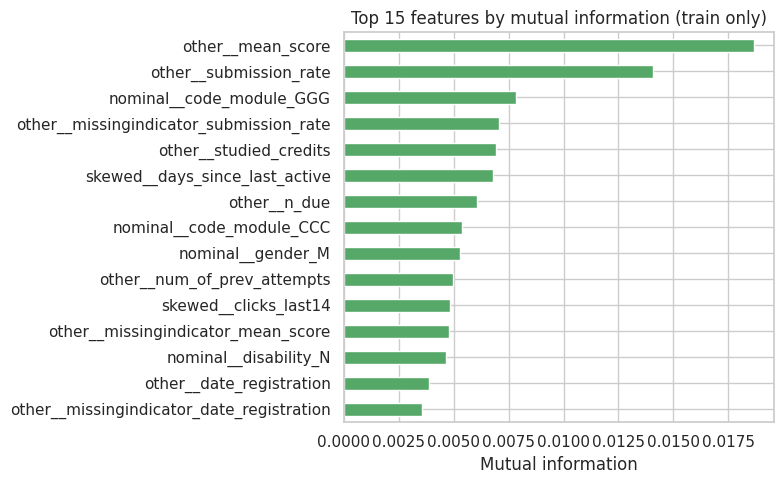

In [29]:
# Feature ranking on the TRAINING data only (mutual information with the target)
mi = mutual_info_classif(Xt_train, y_train, random_state=RANDOM_STATE)
mi_s = pd.Series(mi, index=feature_names).sort_values(ascending=False).head(15)
plt.figure(figsize=(8, 5))
mi_s[::-1].plot(kind="barh", color="#55A868")
plt.title("Top 15 features by mutual information (train only)")
plt.xlabel("Mutual information")
plt.tight_layout(); plt.show()

## 9. Sanity check: does the pipeline run end-to-end without leakage?
We attach two simple models to the pipeline and cross-validate **on the training set only** with student-grouped, stratified folds. In every fold the whole pipeline is re-fitted on the fold's training part, which is what makes this leakage-free. The test set is not touched. This is only a check of the pipeline, not our model comparison (that begins in Part 2).

In [30]:
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {"roc_auc": "roc_auc", "pr_auc": "average_precision", "f1": "f1"}

candidates = {
    "Dummy (stratified)": DummyClassifier(strategy="stratified", random_state=RANDOM_STATE),
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced"),
}

rows = []
for name, clf in candidates.items():
    pipe = Pipeline([("prep", preprocessor), ("var", VarianceThreshold(0.0)), ("clf", clf)])
    res = cross_validate(pipe, X_train, y_train, groups=g_train, cv=cv, scoring=scoring, n_jobs=-1)
    rows.append({"model": name, **{k: f"{res['test_' + k].mean():.3f} ± {res['test_' + k].std():.3f}" for k in scoring}})

pd.DataFrame(rows).set_index("model")

,roc_auc,pr_auc,f1
model,,,
Dummy (stratified),0.506 ± 0.005,0.152 ± 0.003,0.158 ± 0.008
Logistic Regression,0.711 ± 0.010,0.306 ± 0.016,0.370 ± 0.012


**Result note — fill in with your real numbers from the table above.** The logistic regression should beat the dummy baseline clearly on PR-AUC and F1 if the engineered features carry signal. If the scores look *suspiciously* perfect, suspect leakage and re-check the feature list in section 5.

## 10. Leakage audit (for the viva)
| Leakage risk | How this notebook prevents it |
|---|---|
| Target or outcome used as input | `final_result` and `date_unregistration` are excluded; an `assert` guards the feature list |
| Future information | VLE rows are filtered to `date <= CUTOFF_DAY` while reading; assessments to `date_submitted <= CUTOFF_DAY` |
| Students who already left | Removed from the cohort (they are not "at risk" at prediction time) |
| Preprocessing fitted on all data | Imputers, winsorising limits, scalers, encoders and the variance filter are inside the `Pipeline`, fitted on training folds only |
| Same student in train and test | `GroupShuffleSplit` and `StratifiedGroupKFold` split by `id_student` |
| Test set used for decisions | EDA, feature ranking and CV all use training data only |

## 11. Hand-off to Part 2
* The `preprocessor` object and the `X_train / X_test / y_train / y_test` split are reused unchanged in Part 2 (Naive Bayes vs decision tree). Note: Gaussian/Multinomial Naive Bayes may need a different encoding (e.g. non-negative features for Multinomial NB), so add a model-specific variant of the pipeline there rather than changing this one.
* Part 3 can compare cutoffs (30/60/90 days) using the same `CUTOFF_DAY` setting.